Path to dataset files: C:\Users\Shubham\.cache\kagglehub\datasets\balraj98\berkeley-segmentation-dataset-500-bsds500\versions\1
Total images found: 500
Total ground truth files found: 500
Total samples: 4000
Boundary pixels: 2000  Non-boundary pixels: 2000
Training samples: 3200  Testing samples: 800
k = 1  Accuracy = 0.5962
k = 3  Accuracy = 0.6375
k = 5  Accuracy = 0.6625
k = 7  Accuracy = 0.665
k = 9  Accuracy = 0.6775
k = 11  Accuracy = 0.675
Best k = 9
TP = 264  FP = 126  FN = 132  TN = 278
Accuracy  = 0.6775
Precision = 0.6769
Recall    = 0.6667
F1 Score  = 0.6718


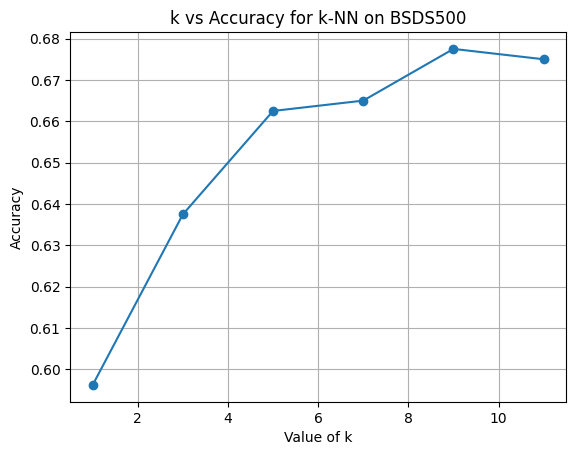

In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.io import loadmat
from scipy.ndimage import uniform_filter, sobel, laplace, maximum_filter, minimum_filter
import kagglehub

path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500")
print("Path to dataset files:", path)

images = sorted(glob.glob(path + "/**/*.jpg", recursive=True))
gtmap = {}
for m in glob.glob(path + "/**/*.mat", recursive=True):
    gtmap[os.path.basename(m)[:-4]] = m

print("Total images found:", len(images))
print("Total ground truth files found:", len(gtmap))


def get_features(f):
    g = np.array(Image.open(f).convert("L"), dtype=float) / 255.0
    gx = sobel(g, axis=0)
    gy = sobel(g, axis=1)
    grad = np.sqrt(gx * gx + gy * gy)
    mean = uniform_filter(g, 5)
    std = np.sqrt(np.abs(uniform_filter(g * g, 5) - mean * mean))
    lap = np.abs(laplace(g))
    rng = maximum_filter(g, 3) - minimum_filter(g, 3)
    F = np.stack([g, grad, mean, std, lap, rng], axis=2)
    return F.reshape(-1, 6), g.shape


def get_labels(name, shape):
    d = loadmat(gtmap[name])["groundTruth"]
    b = np.zeros(shape)
    for i in range(d.shape[1]):
        b = b + d[0, i]["Boundaries"][0, 0]
    return (b > 0).astype(int).reshape(-1)


def build_dataset(n_images, per_class):
    X = []
    Y = []
    for f in images[:n_images]:
        name = os.path.basename(f)[:-4]
        if name not in gtmap:
            continue
        F, shape = get_features(f)
        L = get_labels(name, shape)
        pos = np.where(L == 1)[0]
        neg = np.where(L == 0)[0]
        k = min(per_class, len(pos), len(neg))
        if k == 0:
            continue
        pos = np.random.choice(pos, k, replace=False)
        neg = np.random.choice(neg, k, replace=False)
        idx = np.concatenate([pos, neg])
        X.append(F[idx])
        Y.append(L[idx])
    return np.vstack(X), np.concatenate(Y)


np.random.seed(1)
X, y = build_dataset(20, 100)
X = (X - X.mean(axis=0)) / X.std(axis=0)

p = np.random.permutation(len(X))
X = X[p]
y = y[p]
s = int(0.8 * len(X))
Xtr, Xte = X[:s], X[s:]
ytr, yte = y[:s], y[s:]

print("Total samples:", len(X))
print("Boundary pixels:", int(y.sum()), " Non-boundary pixels:", int(len(y) - y.sum()))
print("Training samples:", len(Xtr), " Testing samples:", len(Xte))


def knn_predict(Xtr, ytr, Xte, k):
    out = []
    for i in range(len(Xte)):
        d = np.sqrt(((Xtr - Xte[i]) ** 2).sum(axis=1))
        idx = np.argsort(d)[:k]
        out.append(1 if ytr[idx].sum() > k / 2 else 0)
    return np.array(out)


ks = [1, 3, 5, 7, 9, 11]
accs = []
for k in ks:
    pred = knn_predict(Xtr, ytr, Xte, k)
    a = (pred == yte).mean()
    accs.append(a)
    print("k =", k, " Accuracy =", round(a, 4))

best = ks[int(np.argmax(accs))]
print("Best k =", best)

pred = knn_predict(Xtr, ytr, Xte, best)
tp = int(((pred == 1) & (yte == 1)).sum())
tn = int(((pred == 0) & (yte == 0)).sum())
fp = int(((pred == 1) & (yte == 0)).sum())
fn = int(((pred == 0) & (yte == 1)).sum())
prec = tp / (tp + fp)
rec = tp / (tp + fn)

print("TP =", tp, " FP =", fp, " FN =", fn, " TN =", tn)
print("Accuracy  =", round((tp + tn) / len(yte), 4))
print("Precision =", round(prec, 4))
print("Recall    =", round(rec, 4))
print("F1 Score  =", round(2 * prec * rec / (prec + rec), 4))

plt.plot(ks, accs, marker="o")
plt.xlabel("Value of k")
plt.ylabel("Accuracy")
plt.title("k vs Accuracy for k-NN on BSDS500")
plt.grid(True)
plt.show()
